<a href="https://colab.research.google.com/github/Prateekpkini/Intent_and_trajectory/blob/main/Intent_and_trajectory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Install the nuScenes development kit
!pip install nuscenes-devkit

# 2. Mount Google Drive to access your downloaded nuScenes data
from google.colab import drive
drive.mount('/content/drive')

# 3. Define the path where you stored the 'v1.0-mini' or 'v1.0-trainval' data
# Structure should be: /data/sets/nuscenes/samples, /metadata, etc.
DATAROOT = '/content/drive/MyDrive/nuScenes_Data'

# import tarfile
# import os

# # Define your paths
# tgz_path = '/content/drive/MyDrive/nuScenes_Data/v1.0-mini.tgz'
# extract_path = '/content/drive/MyDrive/nuScenes_Data'

# # Create directory if it doesn't exist
# if not os.path.exists(extract_path):
#     os.makedirs(extract_path)

# # Extracting the file
# with tarfile.open(tgz_path, 'r:gz') as tar:
#     tar.extractall(path=extract_path)

# print("Extraction complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from nuscenes import NuScenes
from nuscenes.prediction import PredictHelper
from nuscenes.eval.prediction.splits import get_prediction_challenge_split

# Load the dataset (using 'v1.0-mini' for initial code testing)
nusc = NuScenes(version='v1.0-mini', dataroot=DATAROOT, verbose=True)
helper = PredictHelper(nusc)

def get_mini_split(nusc):
    # We'll just take all instances in the mini set that have a future
    tokens = []
    for scene in nusc.scene:
        first_sample_token = scene['first_sample_token']
        # Use helper to find instances in this scene
        # This is a quick way to get valid testing tokens
        sample = nusc.get('sample', first_sample_token)
        for ann_token in sample['anns']:
            ann = nusc.get('sample_annotation', ann_token)
            # Format: {instance_token}_{sample_token}
            tokens.append(f"{ann['instance_token']}_{first_sample_token}")
    return tokens

train_tokens = get_mini_split(nusc)
print(f"Loaded {len(train_tokens)} tokens from mini-split.")

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 6.573 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
Loaded 328 tokens from mini-split.


In [3]:
import numpy as np
import torch

def get_agent_features(token):
    instance_token, sample_token = token.split("_")

    # 1. Past trajectory (2s @ 2Hz = 5 points including current)
    past_xy = helper.get_past_for_agent(instance_token, sample_token, seconds=2, in_agent_frame=True)

    # 2. Future Ground Truth (6s @ 2Hz = 12 points)
    future_xy = helper.get_future_for_agent(instance_token, sample_token, seconds=6, in_agent_frame=True)

    # 3. Kinematic Features
    vel = helper.get_velocity_for_agent(instance_token, sample_token)
    accel = helper.get_acceleration_for_agent(instance_token, sample_token)
    yaw_rate = helper.get_heading_change_rate_for_agent(instance_token, sample_token)

    # Handle potential NaNs in kinematics
    kinematics = np.nan_to_num(np.array([vel, accel, yaw_rate]))

    return torch.FloatTensor(past_xy), torch.FloatTensor(future_xy), torch.FloatTensor(kinematics)

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SocialAttention(nn.Module):
    """
    Accounts for 'Social Context' by weighing the importance of
    surrounding pedestrians/cyclists (neighbors) relative to the ego agent.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.query = nn.Linear(hidden_dim, hidden_dim)
        self.key = nn.Linear(hidden_dim, hidden_dim)
        self.value = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, ego_feat, neighbor_feats):
        # ego_feat: [Batch, Hidden]
        # neighbor_feats: [Batch, Num_Neighbors, Hidden]
        Q = self.query(ego_feat).unsqueeze(1) # [Batch, 1, Hidden]
        K = self.key(neighbor_feats)          # [Batch, Num_Neighbors, Hidden]
        V = self.value(neighbor_feats)        # [Batch, Num_Neighbors, Hidden]

        # Attention scores (how much to pay attention to each neighbor)
        scores = torch.bmm(Q, K.transpose(1, 2)) / (ego_feat.size(-1) ** 0.5)
        attn_weights = F.softmax(scores, dim=-1)

        # Social context vector
        social_context = torch.bmm(attn_weights, V).squeeze(1) # [Batch, Hidden]
        return social_context

class IntentAndTrajectoryPredictor(nn.Module):
    def __init__(self, num_modes=3, future_steps=6, hidden_dim=128):
        # future_steps=6 corresponds to 3 seconds at 2Hz sampling rate
        # num_modes=3 generates the 3 most likely paths
        super().__init__()
        self.num_modes = num_modes
        self.future_steps = future_steps

        # 1. Temporal Modeling (LSTM for past coordinates/velocity)
        self.encoder = nn.LSTM(input_size=2, hidden_size=hidden_dim, batch_first=True)

        # 2. Social Context Layer
        self.social_attention = SocialAttention(hidden_dim)

        # 3. Fusion Layer
        self.fusion = nn.Linear(hidden_dim * 2, hidden_dim)

        # 4. Multi-modal Prediction Heads
        # Regress to future (x, y) coordinates
        self.reg_head = nn.Linear(hidden_dim, num_modes * future_steps * 2)
        # Classify the probability/confidence of each of the 3 modes
        self.cls_head = nn.Linear(hidden_dim, num_modes)

    def forward(self, past_traj, neighbor_trajs=None):
        """
        past_traj: [Batch, 5, 2] (2 seconds of past motion @ 2Hz)
        neighbor_trajs: [Batch, Num_Neighbors, 5, 2] (Past motion of nearby agents)
        """
        batch_size = past_traj.size(0)

        # Encode ego agent's past trajectory
        _, (h_n, _) = self.encoder(past_traj)
        ego_feat = h_n.squeeze(0)

        # Encode social context (if neighbors exist in the scene)
        if neighbor_trajs is not None and neighbor_trajs.size(1) > 0:
            N = neighbor_trajs.size(1)
            neighbor_trajs_flat = neighbor_trajs.view(batch_size * N, -1, 2)
            _, (h_n_neigh, _) = self.encoder(neighbor_trajs_flat)
            neighbor_feats = h_n_neigh.squeeze(0).view(batch_size, N, -1)

            # Apply Social Attention
            social_context = self.social_attention(ego_feat, neighbor_feats)
        else:
            # No neighbors nearby, use an empty context vector
            social_context = torch.zeros_like(ego_feat)

        # Fuse the ego intent with the social environment context
        fused_feat = F.relu(self.fusion(torch.cat([ego_feat, social_context], dim=1)))

        # Output multi-modal trajectories
        trajectories = self.reg_head(fused_feat).view(batch_size, self.num_modes, self.future_steps, 2)

        # Output probabilities for each trajectory
        logits = self.cls_head(fused_feat)
        probabilities = F.softmax(logits, dim=1)

        return trajectories, probabilities


# import torch.nn as nn
# from torchvision.models import resnet50

# class MTPModel(nn.Module):
#     def __init__(self, num_modes=25, future_steps=12):
#         super().__init__()
#         # Visual Stream: ResNet50 for Raster Maps
#         backbone = resnet50(pretrained=False)
#         self.visual_encoder = nn.Sequential(*list(backbone.children())[:-1])

#         # Temporal Stream: LSTM for past coordinates
#         self.lstm = nn.LSTM(input_size=2, hidden_size=128, batch_first=True)

#         # Fusion and Prediction Head
#         # ResNet50 output (2048) + LSTM output (128)
#         combined_dim = 2048 + 128
#         self.reg_head = nn.Linear(combined_dim, num_modes * future_steps * 2)
#         self.cls_head = nn.Linear(combined_dim, num_modes)

#         self.num_modes = num_modes
#         self.future_steps = future_steps

#     def forward(self, map_raster, past_traj):
#         # 1. Extract visual features
#         vis_feat = self.visual_encoder(map_raster).flatten(1)

#         # 2. Extract temporal features
#         _, (h_n, _) = self.lstm(past_traj)
#         temp_feat = h_n.squeeze(0)

#         # 3. Concatenate and Predict
#         fused = torch.cat([vis_feat, temp_feat], dim=1)

#         trajectories = self.reg_head(fused).view(-1, self.num_modes, self.future_steps, 2)
#         logits = self.cls_head(fused)

#         return trajectories, torch.softmax(logits, dim=1)

In [5]:
def calculate_loss_and_metrics(pred_traj, pred_probs, labels, alpha=1.0):
    """
    Calculates the multi-modal loss alongside ADE and FDE metrics.
    pred_traj: [Batch, 3, 6, 2]
    pred_probs: [Batch, 3]
    labels: [Batch, 6, 2] (Ground truth for the next 3 seconds)
    """
    batch_size = pred_traj.size(0)
    labels_exp = labels.unsqueeze(1) # [Batch, 1, 6, 2]

    # Calculate Euclidean distance between all predicted modes and ground truth
    distances = torch.norm(pred_traj - labels_exp, dim=3) # [Batch, 3, 6]

    # ADE: Mean distance across all 6 future time steps
    ade = distances.mean(dim=2) # [Batch, 3]

    # FDE: Distance at the final time step (t = 3s)
    fde = distances[:, :, -1] # [Batch, 3]

    # Best-of-N (Winner-takes-all) mechanism: Find the predicted mode closest to ground truth
    best_mode_idx = torch.argmin(ade, dim=1)
    batch_idx = torch.arange(batch_size)

    # 1. Regression Loss (Smooth L1 applied ONLY to the best predicted path)
    best_pred = pred_traj[batch_idx, best_mode_idx]
    reg_loss = F.smooth_l1_loss(best_pred, labels)

    # 2. Classification Loss (Encourage model to assign highest probability to the best path)
    cls_loss = F.cross_entropy(pred_probs, best_mode_idx)

    # Total Loss
    total_loss = reg_loss + (alpha * cls_loss)

    # Extract Metrics for logging
    min_ade = ade[batch_idx, best_mode_idx].mean().item()
    min_fde = fde[batch_idx, best_mode_idx].mean().item()

    return total_loss, min_ade, min_fde

# ---- Example Usage Initialization ----
# model = IntentAndTrajectoryPredictor(num_modes=3, future_steps=6)
# loss, ade, fde = calculate_loss_and_metrics(predictions, probs, ground_truth)


# def mtp_loss(pred_traj, pred_probs, labels, alpha=1.0):
#     # labels shape: [batch, 12, 2]
#     # pred_traj shape: [batch, 25, 12, 2]

#     batch_size = pred_traj.size(0)
#     labels_exp = labels.unsqueeze(1) # [batch, 1, 12, 2]

#     # Calculate Average Displacement Error for each mode
#     distances = torch.norm(pred_traj - labels_exp, dim=3)
#     ade = distances.mean(dim=2) # [batch, 25]

#     # Find the "Winner" mode
#     best_mode_idx = torch.argmin(ade, dim=1)

#     # Regression Loss on the winner
#     best_pred = pred_traj[torch.arange(batch_size), best_mode_idx]
#     reg_loss = nn.functional.smooth_l1_loss(best_pred, labels)

#     # Classification Loss to prefer the winner
#     cls_loss = nn.functional.cross_entropy(pred_probs, best_mode_idx)

#     return reg_loss + (alpha * cls_loss)

In [9]:
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

# ---------------------------------------------------------
# 1. PyTorch Dataset Wrapper (With 1D/2D Safeguards & Padding)
# ---------------------------------------------------------
class NuScenesTrajectoryDataset(Dataset):
    def __init__(self, tokens):
        self.tokens = tokens

    def __len__(self):
        return len(self.tokens)

    def __getitem__(self, idx):
        token = self.tokens[idx]

        # Fetch features
        past_xy, future_xy, kinematics = get_agent_features(token)

        # SAFEGUARD: Force tensors to be strictly 2-Dimensional [N, 2]
        past_xy = past_xy.view(-1, 2)
        future_xy = future_xy.view(-1, 2)

        # Ensure past_traj is exactly 5 frames (2 seconds at 2Hz)
        if past_xy.shape[0] < 5:
            pad_len = 5 - past_xy.shape[0]
            if past_xy.shape[0] > 0:
                padding = past_xy[-1:].repeat(pad_len, 1) # Repeat last known position
            else:
                padding = torch.zeros((pad_len, 2)) # Fallback if totally empty
            past_xy = torch.cat([past_xy, padding], dim=0)
        else:
            past_xy = past_xy[:5, :]

        # Ensure future_traj is exactly 6 frames (3 seconds at 2Hz)
        future_xy_3s = future_xy[:6, :]
        if future_xy_3s.shape[0] < 6:
            pad_len = 6 - future_xy_3s.shape[0]
            if future_xy_3s.shape[0] > 0:
                padding = future_xy_3s[-1:].repeat(pad_len, 1) # Repeat last known position
            else:
                padding = torch.zeros((pad_len, 2))
            future_xy_3s = torch.cat([future_xy_3s, padding], dim=0)

        return past_xy, future_xy_3s

# ---------------------------------------------------------
# 2. Hyperparameters & Setup
# ---------------------------------------------------------
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Dataset and DataLoader
# (Assumes 'train_tokens' was generated in Cell 3)
train_dataset = NuScenesTrajectoryDataset(train_tokens)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Initialize the Model and Optimizer
model = IntentAndTrajectoryPredictor(num_modes=3, future_steps=6, hidden_dim=128).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ---------------------------------------------------------
# 3. The Training Loop
# ---------------------------------------------------------
print(f"Starting Training on {DEVICE}...")

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    epoch_ade = 0.0
    epoch_fde = 0.0

    for batch_idx, (past_traj, future_traj) in enumerate(train_loader):
        past_traj = past_traj.to(DEVICE)
        future_traj = future_traj.to(DEVICE)

        optimizer.zero_grad()

        # Forward Pass
        pred_traj, pred_probs = model(past_traj, neighbor_trajs=None)

        # Calculate Loss, ADE, and FDE
        loss, ade, fde = calculate_loss_and_metrics(pred_traj, pred_probs, future_traj)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_ade += ade
        epoch_fde += fde

    num_batches = len(train_loader)

    if num_batches > 0:
        avg_loss = epoch_loss / num_batches
        avg_ade = epoch_ade / num_batches
        avg_fde = epoch_fde / num_batches
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {avg_loss:.4f} | ADE: {avg_ade:.4f} | FDE: {avg_fde:.4f}")
    else:
        print("Not enough data to form a batch. Try reducing BATCH_SIZE.")

print("Training Complete!")

Starting Training on cuda...
Epoch [1/10] | Loss: 2.4039 | ADE: 2.8352 | FDE: 4.7011
Epoch [2/10] | Loss: 2.0583 | ADE: 2.1833 | FDE: 3.9048
Epoch [3/10] | Loss: 1.5954 | ADE: 1.3586 | FDE: 2.6464
Epoch [4/10] | Loss: 1.4613 | ADE: 1.0707 | FDE: 1.8770
Epoch [5/10] | Loss: 1.4016 | ADE: 0.9423 | FDE: 1.6465
Epoch [6/10] | Loss: 1.4154 | ADE: 0.9918 | FDE: 1.7140
Epoch [7/10] | Loss: 1.4070 | ADE: 0.9994 | FDE: 1.7379
Epoch [8/10] | Loss: 1.4378 | ADE: 1.0267 | FDE: 1.7937
Epoch [9/10] | Loss: 1.4322 | ADE: 0.9989 | FDE: 1.7495
Epoch [10/10] | Loss: 1.4219 | ADE: 0.9826 | FDE: 1.7083
Training Complete!


In [10]:
import os

# Create a directory to save models if it doesn't exist
save_dir = '/content/drive/MyDrive/nuScenes_Data/models'
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, 'intent_trajectory_predictor.pth')

# Save the model's learned weights
torch.save(model.state_dict(), save_path)
print(f"Model successfully saved to {save_path}")

Model successfully saved to /content/drive/MyDrive/nuScenes_Data/models/intent_trajectory_predictor.pth


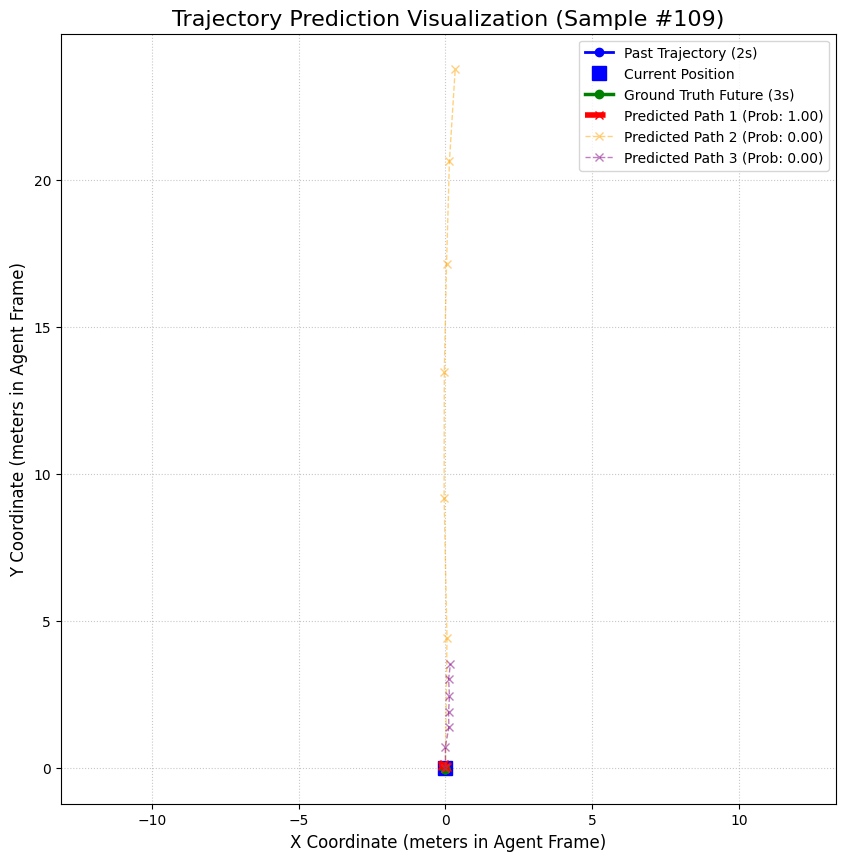

In [11]:
import matplotlib.pyplot as plt
import random

def visualize_prediction(model, dataset, index=None):
    model.eval() # Set model to evaluation mode

    # Pick a random sample if no index is provided
    if index is None:
        index = random.randint(0, len(dataset) - 1)

    with torch.no_grad():
        # Fetch data
        past_traj, future_traj = dataset[index]

        # Add batch dimension and move to device: [1, 5, 2]
        past_traj_batch = past_traj.unsqueeze(0).to(DEVICE)

        # Forward pass to get predictions
        pred_traj, pred_probs = model(past_traj_batch, neighbor_trajs=None)

        # Move tensors back to CPU and convert to numpy for plotting
        past_xy = past_traj.cpu().numpy()
        future_xy = future_traj.cpu().numpy()
        preds = pred_traj.squeeze(0).cpu().numpy()   # Shape: [3, 6, 2]
        probs = pred_probs.squeeze(0).cpu().numpy()  # Shape: [3]

        plt.figure(figsize=(10, 10))

        # 1. Plot Past Trajectory (Blue)
        # We plot the history, and mark the 'current' position (the last point of the past) with a square
        plt.plot(past_xy[:, 0], past_xy[:, 1], 'b-o', label='Past Trajectory (2s)', linewidth=2, markersize=6)
        plt.plot(past_xy[-1, 0], past_xy[-1, 1], 'bs', label='Current Position', markersize=10)

        # 2. Plot Ground Truth Future (Green)
        # We start the line from the current position so it connects visually
        gt_x = np.concatenate(([past_xy[-1, 0]], future_xy[:, 0]))
        gt_y = np.concatenate(([past_xy[-1, 1]], future_xy[:, 1]))
        plt.plot(gt_x, gt_y, 'g-o', label='Ground Truth Future (3s)', linewidth=2.5, markersize=6)

        # 3. Plot the 3 Predicted Modes (Red, Orange, Purple)
        colors = ['red', 'orange', 'purple']
        for i in range(preds.shape[0]):
            pred_x = np.concatenate(([past_xy[-1, 0]], preds[i, :, 0]))
            pred_y = np.concatenate(([past_xy[-1, 1]], preds[i, :, 1]))

            # The line thickness and alpha (transparency) scale with how confident the model is
            plt.plot(pred_x, pred_y, color=colors[i], marker='x', linestyle='--',
                     linewidth=1 + (probs[i] * 3), alpha=0.5 + (probs[i] * 0.5),
                     label=f'Predicted Path {i+1} (Prob: {probs[i]:.2f})')

        # Graph formatting
        plt.title(f"Trajectory Prediction Visualization (Sample #{index})", fontsize=16)
        plt.xlabel("X Coordinate (meters in Agent Frame)", fontsize=12)
        plt.ylabel("Y Coordinate (meters in Agent Frame)", fontsize=12)
        plt.legend(loc='best', fontsize=10)
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.axis('equal') # Ensures 1 meter X = 1 meter Y visually
        plt.show()

# Run the visualization!
# You can run this cell multiple times to see different random samples.
visualize_prediction(model, train_dataset)

In [12]:
import torch
from torch.utils.data import DataLoader
from nuscenes.eval.prediction.splits import get_prediction_challenge_split

def run_validation(model_path=None):
    print("--- Starting Validation ---")

    # 1. Load the Validation Tokens
    # nuScenes provides standard splits. We use 'mini_val' for the mini dataset.
    try:
        val_tokens = get_prediction_challenge_split("mini_val", dataroot=DATAROOT)
        print(f"Loaded {len(val_tokens)} validation tokens.")
    except Exception as e:
        print("Could not load official mini_val split. Splitting training data instead...")
        # Fallback if standard split isn't found in your directory
        split_idx = int(len(train_tokens) * 0.8)
        val_tokens = train_tokens[split_idx:]
        print(f"Using {len(val_tokens)} tokens for validation.")

    # 2. Setup Dataset and DataLoader
    val_dataset = NuScenesTrajectoryDataset(val_tokens)
    # drop_last=False so we don't skip any validation samples
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    # 3. Load the Model Weights (Optional: if running in a fresh session)
    if model_path and os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path))
        print(f"Loaded model weights from {model_path}")

    # 4. Set Model to Evaluation Mode
    model.eval()

    total_val_loss = 0.0
    total_val_ade = 0.0
    total_val_fde = 0.0
    num_batches = len(val_loader)

    if num_batches == 0:
        print("No validation data found!")
        return

    # 5. The Validation Loop (No Gradients)
    with torch.no_grad():
        for batch_idx, (past_traj, future_traj) in enumerate(val_loader):
            past_traj = past_traj.to(DEVICE)
            future_traj = future_traj.to(DEVICE)

            # Forward Pass
            pred_traj, pred_probs = model(past_traj, neighbor_trajs=None)

            # Calculate Metrics
            loss, ade, fde = calculate_loss_and_metrics(pred_traj, pred_probs, future_traj)

            total_val_loss += loss.item()
            total_val_ade += ade
            total_val_fde += fde

    # 6. Calculate Averages
    avg_val_loss = total_val_loss / num_batches
    avg_val_ade = total_val_ade / num_batches
    avg_val_fde = total_val_fde / num_batches

    print("\n--- Validation Results ---")
    print(f"Average Loss: {avg_val_loss:.4f}")
    print(f"Average ADE:  {avg_val_ade:.4f} meters")
    print(f"Average FDE:  {avg_val_fde:.4f} meters")
    print("--------------------------")

    return avg_val_ade, avg_val_fde

# Run the validation script
# Uses the save_path variable defined in Cell 8
val_ade, val_fde = run_validation(model_path=save_path)

--- Starting Validation ---
Could not load official mini_val split. Splitting training data instead...
Using 66 tokens for validation.
Loaded model weights from /content/drive/MyDrive/nuScenes_Data/models/intent_trajectory_predictor.pth

--- Validation Results ---
Average Loss: 1.5279
Average ADE:  0.9952 meters
Average FDE:  1.9419 meters
--------------------------
